<a href="https://colab.research.google.com/github/tjdux/basic_of_ml/blob/main/30_%EC%9D%B4%EB%AF%B8%EC%A7%80_%EB%B6%84%EB%A5%98_%EB%AA%A8%EB%8D%B8%EC%9D%98_%EC%84%B1%EB%8A%A5_%EC%B5%9C%EC%A0%81%ED%99%94%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 가장 높은 성능을 내는 모델 - EfficientNet


### 새로운 활성화 함수 - 스위시
$$f(x) = x \times σ(x)$$

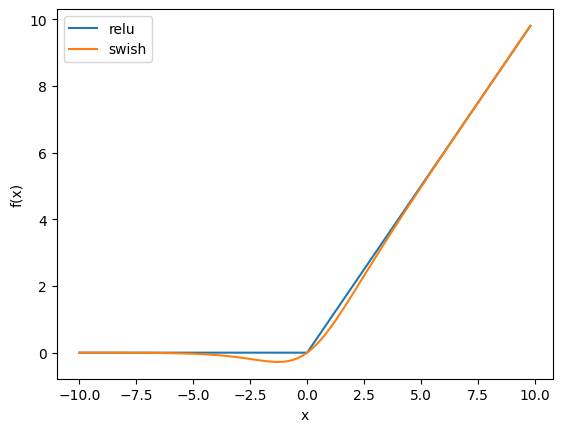

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

x = np.arange(-10, 10, 0.2)

plt.plot(x, x.clip(0), label='relu')
plt.plot(x, x * expit(x), label='swish')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

- 장점: **죽은 뉴런**(dying neuron)이 발생하지 않음
  - 👉 그레이디언트를 0으로 만들지 않기 때문 (모든 지점에서 미분 가능)

- 하드 스위시 함수 (hard swish function)
$$f(x) = \frac{ReLU6(x+3)}{6}$$

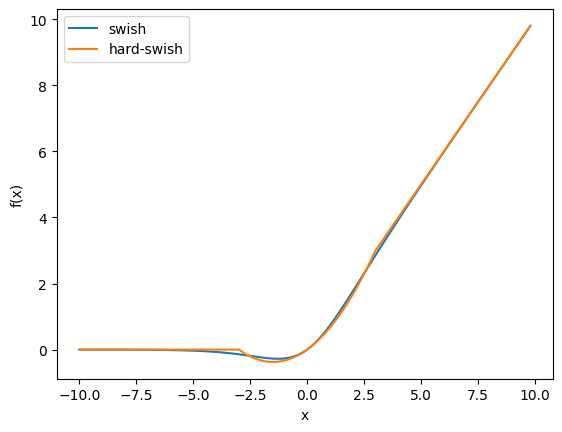

In [3]:
def relu6(x):
  return np.minimum(np.maximum(x, 0), 6)

x = np.arange(-10, 10, 0.2)

plt.plot(x, x*expit(x), label='swish')
plt.plot(x, x*relu6(x+3)/6, label='hard-swish')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

### 성능과 효율을 동시에 잡는 방법 - 복합 스케일링
- EfficientNet: AutoML 기술을 사용해 작은 크기의 신경망을 만든 다음 깊이와 너비, 해상도를 복합적으로 늘려 신경망의 성능을 높이는 **복합 스케일링**(compound scaling) 방식을 처음으로 제안

## EfficientNet 모델 만들기

### 역 잔차 블록 만들기

In [17]:
import keras
from keras import layers

# 역 잔차 블록
def inv_res_block(inputs, filters_out, kernel_size, strides,
                  dropout_rate, expand_ratio):
  # 팽창 단계
  filters_in = inputs.shape[-1]
  filters = filters_in * expand_ratio
  if expand_ratio > 1:
    x = layers.Conv2D(filters, 1, padding='same',
                       use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
  else:
    x = inputs

  # 깊이별 분리 합성곱
  if strides == 2:
    x = layers.ZeroPadding2D(padding=padding_size(x.shape,
                                                  kernel_size))(x)
  x = layers.DepthwiseConv2D(kernel_size, strides=strides,
                             use_bias=False, padding='same'
                             if strides == 1 else 'valid')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('swish')(x)


  # SE 블록
  se_input = x
  x = layers.GlobalAveragePooling2D(keepdims=True)(x)
  x = layers.Conv2D(int(filters_in * 0.25), 1, padding='same',
                    activation='swish')(x)
  x = layers.Conv2D(filters, 1, padding='same', activation='sigmoid')(x)
  x = layers.Multiply()([se_input, x])

  # 출력 단계
  x = layers.Conv2D(filters_out, 1, use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  if strides == 1 and filters_in == filters_out:
    if dropout_rate > 0:
      x = layers.Dropout(dropout_rate, noise_shape=(None, 1, 1, 1))(x)
      x = layers.Add()([x, inputs])

  return x

In [6]:
# 패딩 크기 계산
def padding_size(input_size, kernel_size):
  padding = kernel_size // 2

  if input_size[1] % 2 == 0:
    return ((padding-1, padding),
            (padding-1, padding))
  else:
    return padding

In [9]:
import math

def round_repeats(repeats, depth):
  """repeats * depth 보다 큰 정수를 반환"""
  return int(math.ceil(repeats * depth))

def round_filters(filters, width):
  """filters * width보다 크고 8의 배수가 되도록 만듦"""
  filters *= width
  new_filters = max(8, int(filters+4) // 8 * 8)
  if new_filters < 0.9 * filters:
    new_filters += 8
  return int(new_filters)

### EfficientNet 모델 만들기

In [10]:
depth = 1.0
width = 1.0
inputs = layers.Input(shape=(224, 224, 3))

x = layers.Rescaling(1.0 / 255.0)(inputs)
x = layers.Normalization()(x)
x = layers.Rescaling(1.0 / np.sqrt([0.299, 0.224, 0.225]))(x)
x = layers.ZeroPadding2D(padding=padding_size(x.shape, 3))(x)
x = layers.Conv2D(round_filters(32, width), 3, strides=2, padding='valid',
                  use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('swish')(x)

In [15]:
# 역 잔차 블록 매개변수
blocks_params = [
    {
        'kernel_size': 3,
        'repeats': 1,
        'filters_out': 16,
        'strides': 1
    },
    {
        'kernel_size': 3,
        'repeats': 2,
        'filters_out': 24,
        'strides': 2
    },
    {
        'kernel_size': 5,
        'repeats': 2,
        'filters_out': 40,
        'strides': 2
    },
    {
        'kernel_size': 3,
        'repeats': 3,
        'filters_out': 80,
        'strides': 2
    },
    {
        'kernel_size': 5,
        'repeats': 3,
        'filters_out': 112,
        'strides': 1
    },
    {
        'kernel_size': 5,
        'repeats': 4,
        'filters_out': 192,
        'strides': 2
    },
    {
        'kernel_size': 3,
        'repeats': 1,
        'filters_out': 320,
        'strides': 1
    },
]

In [18]:
# 역 잔차 블록 그룹 반복하기
filter_expand_ratio = 1
block_count = 0
total_blocks = float(sum(round_repeats(params['repeats'],
                                       depth) for params in blocks_params))

for params in blocks_params:
  # depth에 따라 블록의 입력과 출력 필터를 늘림
  filters_out = round_filters(params['filters_out'], width)
  strides = params['strides']
  for j in range(round_repeats(params['repeats'], depth)):
    if j > 0:
      strides = 1
    dropout_rate = 0.2 * block_count / total_blocks
    x = inv_res_block(x, filters_out, params['kernel_size'],
                      strides, dropout_rate, filter_expand_ratio)
    block_count += 1
  filter_expand_ratio = 6

In [19]:
# 모델 만들어 구조 확인하기
x = layers.Conv2D(round_filters(1280, width), 1, padding='same',
                  use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('swish')(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1000, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        864 │ zero_padding2d_1… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 112, 112,  │        288 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1, 32)  │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 1, 1, 8)   │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 1, 1, 32)  │        288 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 112, 112,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │        512 │ multiply[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,331,247 (20.34 MB)

 Trainable params: 5,289,160 (20.18 MB)

 Non-trainable params: 42,087 (164.41 KB)

## EfficientNet 모델로 강아지 사진 분류하기

In [20]:
!gdown 1xGkTT3uwYt4myj6eJJeYtdEFgTi2Sj8C
!unzip cat-dog-images.zip

Downloading...
From: https://drive.google.com/uc?id=1xGkTT3uwYt4myj6eJJeYtdEFgTi2Sj8C
To: /content/cat-dog-images.zip
100% 182k/182k [00:00<00:00, 83.8MB/s]
Archive:  cat-dog-images.zip
   creating: images/
  inflating: images/dog.png          
  inflating: images/cat.png          


In [23]:
from PIL import Image
from keras.applications import efficientnet

dog_png = np.array(Image.open('images/dog.png'))

efficientb0 = keras.applications.EfficientNetB0()
predictions = efficientb0.predict(dog_png[np.newaxis, :])
efficientnet.decode_predictions(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n02099712', 'Labrador_retriever', np.float32(0.36829436)),
  ('n02104029', 'kuvasz', np.float32(0.19339848)),
  ('n02099601', 'golden_retriever', np.float32(0.06145822)),
  ('n02111500', 'Great_Pyrenees', np.float32(0.05779685)),
  ('n02095889', 'Sealyham_terrier', np.float32(0.017902818))]]